A1. What is a tensor, and how is it different from a normal Python list? Give one everyday example of data that could be stored as a tensor.
A tensor is basically a multi-dimensional array, kind of like a list of lists in python but optimized for fast math operations. An everyday example could be an image, which can be stored as a 3D tensor (height, width, and RGB color channels).

A2. What do the terms shape, ndim (dimensions), and dtype tell you about a tensor?
Shape tells us the exact size of the tensor in each dimension (like 3x4). ndim tells us the total number of dimensions (like 2D or 3D). dtype tells us the type of data it holds, like integer or float.

A3. Why do we sometimes move tensors and models to a GPU? What problem does it solve?
Deep learning involves millions of math operations. CPUs are good at doing things one by one, but GPUs can do thousands of math operations at the same time. Moving tensors to GPU makes training much faster.

A4. In machine learning, what is the difference between training data and test data, and why must we keep them separate?
Training data is the data we use to teach the model. Test data is kept completely hidden during training. We keep them separate to test if the model can actually predict on new data, rather than just memorizing the training set.

A5. In your own words, what is a model actually "learning" when we train it? (Hint: think about weights and bias.)
The model is basically adjusting its weights and bias values to make its predictions closer to the actual answers. It learns the mathematical pattern.

Part B — Tensor Basics (Code Cells)

In [2]:
#B1
import torch

t1 = torch.arange(1, 11)
print(t1)
print(t1.shape)
print(t1.ndim)
print(t1.dtype)

tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
torch.Size([10])
1
torch.int64


In [3]:
#B2
t_a = torch.rand(3, 4)
t_b = torch.rand(4, 2)
res = torch.matmul(t_a, t_b)
print(res.shape)

torch.Size([3, 2])


In [4]:
#B3
print(t_a.min())
print(t_a.max())
print(t_a.mean())
print(t_a.sum())

tensor(0.0127)
tensor(0.8849)
tensor(0.5823)
tensor(6.9873)


In [5]:
#B4
t_step = torch.arange(0, 100, 10)
t_reshaped = t_step.reshape(2, 5)
print(t_reshaped)

tensor([[ 0, 10, 20, 30, 40],
        [50, 60, 70, 80, 90]])


In [6]:
#B5
torch.manual_seed(42)
rand_t = torch.rand(2, 3)
print(rand_t)

tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009]])


B5 explanation: Why is setting a random seed useful?
Setting a seed makes sure that the random numbers generated are the same every time we run the code. This makes it easier to debug.

Part C — Mini-Project (Code Cells)

In [7]:
weight, bias = 0.7, 0.3

X = torch.arange(0, 1, 0.02).unsqueeze(1)
y = weight * X + bias

print("X shape:", X.shape, "| y shape:", y.shape)
print("First 5 X values:", X[:5].squeeze())
print("First 5 y values:", y[:5].squeeze())

X shape: torch.Size([50, 1]) | y shape: torch.Size([50, 1])
First 5 X values: tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800])
First 5 y values: tensor([0.3000, 0.3140, 0.3280, 0.3420, 0.3560])


In [8]:
#C1
train_split = int(0.8 * len(X))

X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

print(len(X_train))
print(len(X_test))

40
10


In [9]:
#C2
from torch import nn

class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

torch.manual_seed(42)
model = SimpleModel()

In [10]:
#C3
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [11]:
#C4
epochs = 200

for epoch in range(epochs):
    model.train()

    preds = model(X_train)
    loss = loss_fn(preds, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item()}")

Epoch 0 | Loss: 0.5551779866218567
Epoch 20 | Loss: 0.3247582018375397
Epoch 40 | Loss: 0.09433844685554504
Epoch 60 | Loss: 0.0199567973613739
Epoch 80 | Loss: 0.013089170679450035
Epoch 100 | Loss: 0.006215679459273815
Epoch 120 | Loss: 0.0012645035749301314
Epoch 140 | Loss: 0.0012645035749301314
Epoch 160 | Loss: 0.0012645035749301314
Epoch 180 | Loss: 0.0012645035749301314


In [12]:
#C5
print(model.state_dict())

OrderedDict({'linear.weight': tensor([[0.6968]]), 'linear.bias': tensor([0.3025])})


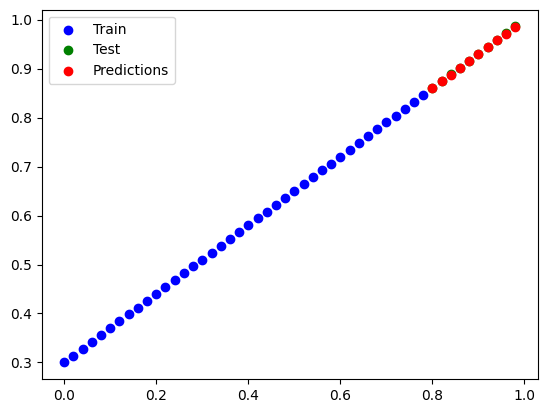

In [13]:
#C6
import matplotlib.pyplot as plt

model.eval()
with torch.inference_mode():
    test_preds = model(X_test)

plt.scatter(X_train.numpy(), y_train.numpy(), color='blue', label='Train')
plt.scatter(X_test.numpy(), y_test.numpy(), color='green', label='Test')
plt.scatter(X_test.numpy(), test_preds.numpy(), color='red', label='Predictions')
plt.legend()
plt.show()

Part D — Reflection
D1. What was the single most confusing thing this week, and how did you (try to) figure it out?
The most confusing part was understanding why we need to do optimizer.zero_grad() in every loop. I figured out that pytorch keeps adding up the gradients by default, so we have to clear them before the next step otherwise the math gets messed up.

D2. Which of the five training-loop steps (predict → loss → zero gradients → backprop → step) still feels fuzzy?
The backprop step (loss.backward()) still feels a bit fuzzy. I understand that it calculates the gradients to fix the error, but exactly how it does all that calculus under the hood without me writing any formulas is still kind of a black box to me.

D3. On a scale of 1–5, how comfortable do you feel with tensors now? One line on why.
I would say a 4. I feel comfortable with them because they act basically just like numpy arrays or matrices, which I have used before, just with some new pytorch specific commands to remember.

Bonus (Optional)

In [14]:
torch.manual_seed(42)
model_bonus = SimpleModel()
opt_bonus = torch.optim.SGD(model_bonus.parameters(), lr=1.0)
loss_fn_bonus = nn.L1Loss()

for epoch in range(50):
    model_bonus.train()
    p = model_bonus(X_train)
    l = loss_fn_bonus(p, y_train)

    opt_bonus.zero_grad()
    l.backward()
    opt_bonus.step()

    if epoch % 10 == 0:
         print(f"Epoch {epoch} loss: {l.item()}")

Epoch 0 loss: 0.5551779866218567
Epoch 10 loss: 0.5551779866218567
Epoch 20 loss: 0.5551779866218567
Epoch 30 loss: 0.5551779866218567
Epoch 40 loss: 0.5551779866218567


With learning rate 1.0, the loss jumps around and doesn't decrease properly because the steps are too big. With 0.0001 it decreases but extremely slowly.
For classification, I noticed we use different things like CrossEntropyLoss instead of L1Loss because we are predicting categories instead of numbers.